In [12]:
import numpy as np
import pandas as pd
from obspy import UTCDateTime

import matplotlib.pyplot as plt
from pathlib import Path

import re
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [13]:
#Finally, only HH3 for station VRG01

df_s1 = pd.read_parquet("year_Virgo_results_cut/qtransform_features.parquet")
df_s1 = df_s1.drop(columns=['year'])
df_s2 = pd.read_parquet("Virgo_results_cut/O3bqtransform_features.parquet")
df_s2 = df_s2[df_s2["channel"] == 'HH3']
df_s2 = df_s2[df_s2["station"] == 'VRG01']
df_s2 = df_s2.drop(columns=['run'])

df_s = pd.concat([df_s1, df_s2], ignore_index=True)

#print(df_s.head(5))

In [ ]:
GPS_UNIX_OFFSET = 315964800
GPS_UTC_OFFSET = 18
WINDOW_SECONDS = 12

df_g = pd.read_csv("gravity_spy_O3b.csv")
df_g["trigger_time"] = df_g["GPStime"].apply(lambda gps: UTCDateTime(gps + GPS_UNIX_OFFSET - GPS_UTC_OFFSET).datetime)

df_s_match = df_s[["trigger_time", "file"]].copy()
df_g_match = df_g[["trigger_time", "label"]].copy()

df_s_match["trigger_time"] = pd.to_datetime(df_s_match["trigger_time"], utc=True)
df_g_match["trigger_time"] = pd.to_datetime(df_g_match["trigger_time"], utc=True)

# Sort
df_s_match = df_s_match.sort_values("trigger_time").reset_index(drop=True)
df_g_match = df_g_match.sort_values("trigger_time").reset_index(drop=True)

g_times = df_g_match["trigger_time"].to_numpy()
s_times = df_s_match["trigger_time"].to_numpy()

window = pd.Timedelta(seconds=WINDOW_SECONDS).to_numpy()
matched_rows = []
matched_s_indices = set()
matched_g_indices = set()

for s_idx, s_time in enumerate(s_times):
    left = s_time - window
    right = s_time + window

    start = g_times.searchsorted(left, side="left")  
    end = g_times.searchsorted(right, side="right")  
    g_indices = range(start, end)  

    for g_idx in g_indices:

        matched_rows.append({"file": df_s_match.iloc[s_idx]["file"], "trigger (df_s)": df_s_match.iloc[s_idx]["trigger_time"],
                             "trigger (df_g)": df_g_match.iloc[g_idx]["trigger_time"], "label": df_g_match.iloc[g_idx]["label"],})

        matched_s_indices.add(s_idx)
        matched_g_indices.add(g_idx)


df_matched = pd.DataFrame(matched_rows, columns=["file", "trigger (df_s)", "trigger (df_g)", "label"])
df_matched = df_matched.reset_index(drop=True)

#print(df_matched.head(5))
#print(f"Number of matched rows: {len(df_matched)}")

In [ ]:
RANDOM_STATE = 42
df = df_s.copy()

feature_columns = [col for col in df.columns if col.startswith("feature")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df[feature_columns].to_numpy(dtype="float64")
print(f"X.shape = {X.shape}")

X_max = X.max(axis=1, keepdims=True)
#X_max = X_max.T
#print(X_max[0])

Number of features: 1230
X.shape = (8771, 1230)


In [ ]:
for row in X:
    X_norm = X / X_max

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)
print(f"Scaled matrix: {X_scaled.shape}") 

Scaled matrix: (8771, 1230)


In [ ]:
PCA_COMPONENTS = 40

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=100,early_exaggeration=300,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X_pca)

PCA components: 40
Explained variance: 0.5374


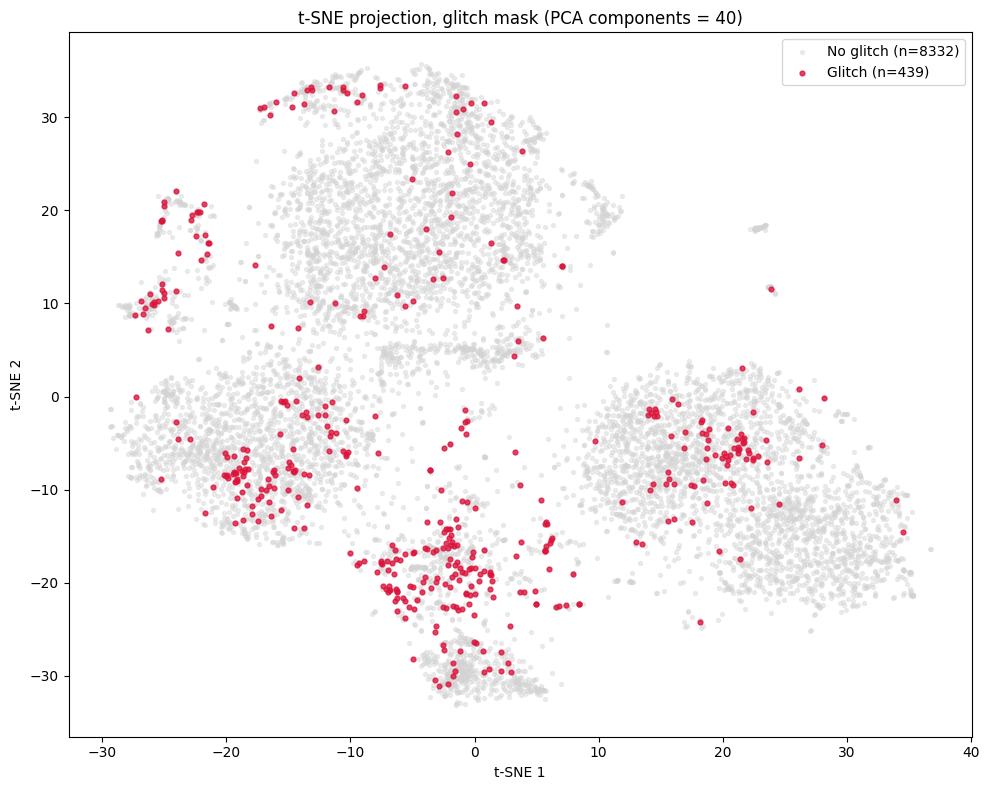

In [ ]:
glitch_files = set(df_matched["file"].unique())
mask = df["file"].isin(glitch_files).to_numpy()

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(X_tsne[~mask, 0], X_tsne[~mask, 1],
           s=8, alpha=0.4, color="lightgray", zorder=1,
           label=f"No glitch (n={(~mask).sum()})")

ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
           s=12, alpha=0.8, color="crimson", zorder=2,
           label=f"Glitch (n={mask.sum()})")

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title(f"t-SNE projection, glitch mask)")
ax.legend()
plt.tight_layout()
plt.show()

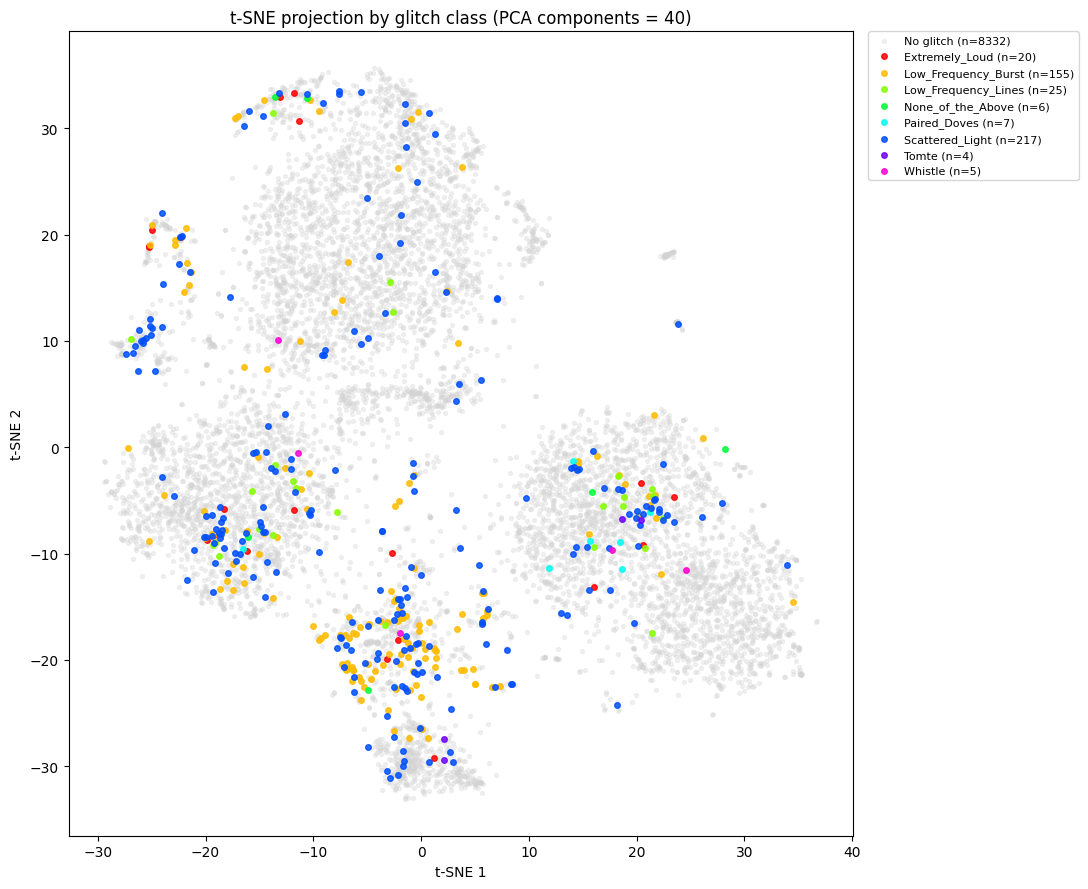

In [ ]:
file_label = df_matched.groupby("file")["label"].agg(lambda s: s.value_counts().idxmax())

labels = df["file"].map(file_label).fillna("No glitch")
glitch_classes = sorted(c for c in labels.unique() if c != "No glitch")

cmap = plt.get_cmap("hsv", len(glitch_classes) + 1)
class_colors = {cls: cmap(i) for i, cls in enumerate(glitch_classes)}

fig, ax = plt.subplots(figsize=(11, 9))

no_glitch_mask = (labels == "No glitch").to_numpy()
ax.scatter(X_tsne[no_glitch_mask, 0], X_tsne[no_glitch_mask, 1],
           s=8, alpha=0.3, color="lightgray", zorder=1,
           label=f"No glitch (n={no_glitch_mask.sum()})")

for cls in glitch_classes:
    cls_mask = (labels == cls).to_numpy()
    ax.scatter(X_tsne[cls_mask, 0], X_tsne[cls_mask, 1],
               s=16, alpha=0.85, color=class_colors[cls], zorder=2,
               label=f"{cls} (n={cls_mask.sum()})")

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title(f"t-SNE projection by glitch class)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()

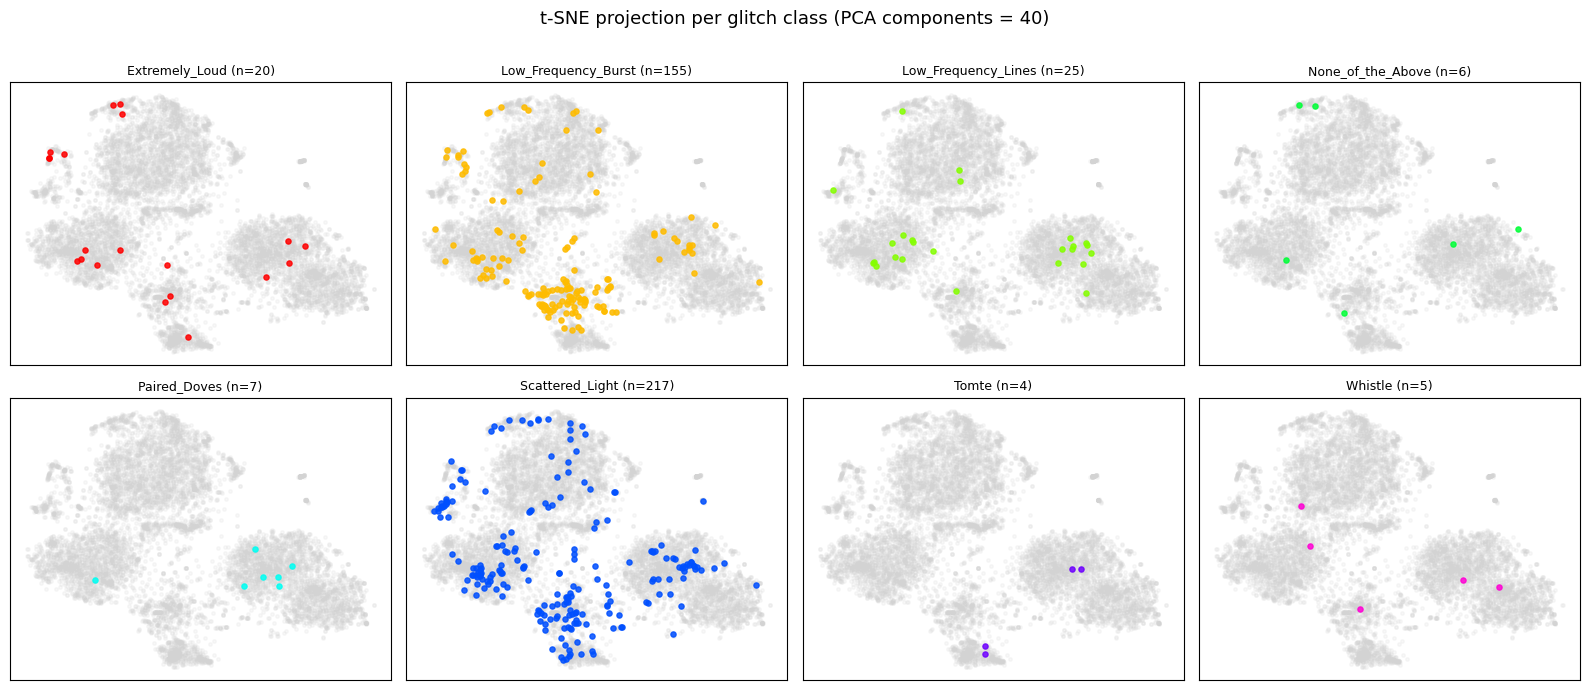

In [ ]:
ncols = 4
nrows = int(np.ceil(len(glitch_classes) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows),
                          sharex=True, sharey=True)
axes = axes.flatten()

for ax, cls in zip(axes, glitch_classes):
    cls_mask = (labels == cls).to_numpy()

    ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
               s=6, alpha=0.15, color="lightgray", zorder=1)
    ax.scatter(X_tsne[cls_mask, 0], X_tsne[cls_mask, 1],
               s=14, alpha=0.85, color=class_colors[cls], zorder=2)

    ax.set_title(f"{cls} (n={cls_mask.sum()})", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide any unused grid cells if class count isn't a multiple of ncols
for ax in axes[len(glitch_classes):]:
    ax.axis("off")

fig.suptitle(f"t-SNE projection per glitch class)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
import os
from pathlib import Path

import numpy as np
import pymupdf
import plotly.graph_objects as go
import ipywidgets as widgets

from IPython.display import display, Image, clear_output

#TODO: fix this

PATH = Path("year_Virgo_results_cut")
PDF_DPI = 150
IMAGE_WIDTH = 900

# I don't know why it works this way, but it only works this way so please don't remove these four following lines

if "label" not in df.columns:
    df["label"] = "Unlabeled"

label_map = df.drop_duplicates("file").set_index("file")["label"]
df["label"] = df["file"].map(label_map).fillna("Unlabeled")
df["run"] = df["file"].map(label_map).fillna("Unlabeled")


def parse_date_from_filename(filename):
    filename = str(filename)
    match = re.search(r"(20\d{2})-(\d{2})-(\d{2})", filename)
    if match is None:
        raise ValueError(
            f"Could not extract date from filename: {filename}")

    year, month, day = match.groups()

    return pd.Timestamp(year=int(year),month=int(month),day=int(day))


df["_file_date"] = df["file"].apply(parse_date_from_filename)
df["_day_str"] = df["_file_date"].dt.strftime("%Y%m%d")
df["_qtransform_index"] = (df.groupby(["run","station","channel","month_year","_day_str"],sort=False).cumcount())


# ---------------------------------------------------------
# Build PDF path
# ---------------------------------------------------------

def get_qtransform_path(df_index):
    row = df.iloc[df_index]

    run = Path(str(row["year"]))
    station = str(row["station"])
    channel = str(row["channel"])
    month_year = str(row["month_year"])

    day_str = str(row["_day_str"])
    i = int(row["_qtransform_index"])
    file = f"qtransform_{day_str}_{i:06d}.pdf"
    pdf_path = (PATH/run/station/channel/month_year/file)

    return pdf_path

customdata = np.column_stack([np.arange(len(df)),df["file"].astype(str).values,df["label"].astype(str).values])

fig = go.FigureWidget(
    data=[go.Scatter(
        x=X_tsne[:, 0], y=X_tsne[:, 1],
        mode="markers",
        marker=dict(size=5, opacity=0.5),
        customdata=customdata,
        hovertemplate=(
            "<b>DataFrame index:</b> %{customdata[0]}<br>"
            "<b>File:</b> %{customdata[1]}<br>"
            "<b>Label:</b> %{customdata[2]}<br>"
            "<b>t-SNE 1:</b> %{x:.3f}<br>"
            "<b>t-SNE 2:</b> %{y:.3f}"
            "<extra></extra>"
        ),
    )]
)

fig.update_layout(
    title=(f"Perplexity = 90 | Early Exaggeration = 14 | PCA Components = {PCA_COMPONENTS} | Metric = cosine"),
    xaxis_title="t-SNE 1", yaxis_title="t-SNE 2", width=1000, height=800, hovermode="closest")

image_output = widgets.Output(layout=widgets.Layout(width="1000px"))

pdf_cache = {}

def render_pdf(pdf_path, dpi=PDF_DPI):
    if not os.path.exists(pdf_path):
        raise FileNotFoundError(f"PDF not found:\n{pdf_path}")

    if pdf_path in pdf_cache:
        return pdf_cache[pdf_path]

    pdf = pymupdf.open(pdf_path)

    try:
        if len(pdf) == 0:
            raise ValueError("PDF contains no pages.")
        page = pdf[0]
        zoom = dpi / 72.0
        matrix = pymupdf.Matrix(zoom, zoom)
        pix = page.get_pixmap(matrix=matrix, alpha=False)
        png_bytes = pix.tobytes("png")

        pdf_cache[pdf_path] = png_bytes
        return png_bytes
    finally:
        pdf.close()


def display_qtransform(df_index, file, label, point_position):
    pdf_path = get_qtransform_path(df_index)

    with image_output:
        clear_output(wait=True)

        print(f"DataFrame index : {df_index}")
        print(f"File            : {file}")
        print(f"Label           : {label}")
        print(f"PDF             : {pdf_path}")
        print(
            f"t-SNE           : "
            f"({X_tsne[point_position, 0]:.4f}, "
            f"{X_tsne[point_position, 1]:.4f})"
        )
        print()

        try:
            png_bytes = render_pdf(pdf_path, dpi=PDF_DPI)
            display(Image(data=png_bytes, width=IMAGE_WIDTH))

        except FileNotFoundError as e:
            print("ERROR: PDF file was not found.")
            print(e)

        except Exception as e:
            print("ERROR while rendering PDF:")
            print(e)



def on_click(trace, points, selector):
    if not points.point_inds:
        return

    point_position = points.point_inds[0]
    df_index = int(trace.customdata[point_position][0])
    file = str(trace.customdata[point_position][1])
    label = str(trace.customdata[point_position][2])
    display_qtransform(df_index=df_index, file=file, label=label, point_position=point_position)

fig.data[0].on_click(on_click)
display(fig)
display(image_output)

FigureWidget({
    'data': [{'customdata': array([[0, 'VRG01_HH3_2022-01-02.mseed', 'Unlabeled'],
                                   [1, 'VRG01_HH3_2022-01-02.mseed', 'Unlabeled'],
                                   [2, 'VRG01_HH3_2022-01-02.mseed', 'Unlabeled'],
                                   ...,
                                   [8768, 'VRG01_HH3_2020-03-27.mseed', 'Unlabeled'],
                                   [8769, 'VRG01_HH3_2020-03-27.mseed', 'Unlabeled'],
                                   [8770, 'VRG01_HH3_2020-03-27.mseed', 'Unlabeled']],
                                  shape=(8771, 3), dtype=object),
              'hovertemplate': ('<b>DataFrame index:</b> %{cust' ... '2:</b> %{y:.3f}<extra></extra>'),
              'marker': {'opacity': 0.5, 'size': 5},
              'mode': 'markers',
              'type': 'scatter',
              'uid': '2a2d2d98-0ed5-4d7e-8d22-266ffd089f17',
              'x': {'bdata': ('FjtOwaeQA8G9pmLBHF9swdstm0HQPu' ... 'rBYTT4wEONMcF/GF7BX

Output(layout=Layout(width='1000px'))